# Numpy
NumPy-based algorithms are generally **10 to 100 times faster** (or more) than their pure Python counterparts and **use significantly less memory**.

In [2]:
import numpy as np

## Array Creation

In [3]:
# my_list = list(range(1000000)) # Took more than 3 minutes
my_arr = np.arange(1000000) # Took only 0.023 seconds

# print(my_list)
print(my_arr)

[     0      1      2 ... 999997 999998 999999]


In [4]:

arr1 = np.array([1,2,3,4]) #1d array
print(arr1)
print("-----------------")

arr2 = np.array([[1,2,3,4],[5,6,7,8]]) #2d array
print(arr2)
print("-----------------")

arr3 = np.array([[[1,2],[3,4],[5,6]]]) #3d array
print(arr3)
print("-----------------")

[1 2 3 4]
-----------------
[[1 2 3 4]
 [5 6 7 8]]
-----------------
[[[1 2]
  [3 4]
  [5 6]]]
-----------------


In [5]:
# Array of Zeros

zeros = np.zeros(5) #1d array of 5 zeros
zeros2D = np.zeros((3,4)) # 2d array of zeros , 3x4 size of array

#Array of Ones
ones = np.ones((2,3))
print(ones)

#Identity Array
print("======> Identity Array: ")
identity = np.eye(3)
print(identity)


#Random Value Array
print("======> Random Values Array: ")
identity = np.random.random((2,2)) # [0, 1) - Between 0 (inclusive) and 1 (exlusive)
print(identity)

[[1. 1. 1.]
 [1. 1. 1.]]
======> Identity Array: 
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
======> Random Values Array: 
[[0.96854105 0.212437  ]
 [0.93510147 0.77643919]]


## Array Properties

In [6]:
arr = np.array([[1, 2, 3], [4, 5, 6]])

print("Array:", arr)
print("Shape:", arr.shape)      # Dimensions: (2, 3)
print("Number of dimensions:", arr.ndim)  # 2
print("Number of elements:", arr.size)    # 6
print("Data type:", arr.dtype)  # int64 (depends on system)
print("Number of Bytes:", arr.nbytes)  # Each element - 8 bytes (depends on system)

Array: [[1 2 3]
 [4 5 6]]
Shape: (2, 3)
Number of dimensions: 2
Number of elements: 6
Data type: int64
Number of Bytes: 48


## Array Integer Indexing and Slicing

In [7]:
arr = np.array([10, 20, 30, 40, 50])

print(arr[0])    # Output: 10 (first element)
print(arr[-1])   # Output: 50 (last element)
print(arr[1:4])  # Output: [20 30 40] (slicing)
# You can also use arr[:2, 1:3].copy() to avoid referencing the original array

arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

print(arr[0, 0])     # Output: 1 (row 0, column 0)
print(arr[1, 2])     # Output: 6 (row 1, column 2)
print(arr[0:2, 1:3]) # Output: [[2 3] [5 6]] (slicing)

10
50
[20 30 40]
1
6
[[2 3]
 [5 6]]


Two ways of accessing the data in the middle row of the array.
**Mixing integer indexing** with slices yields an array of **lower rank**,
while using **only slices yields** an array of the **same rank** as the
original array:

In [8]:
a = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

print(a[1, :2]) # Rank 1: (rows (1), columns (0, 1))
print()
print(a[1:3, :2]) # Rank 2 (original rank): (rows (1, 2), columns (0, 1))
print()
print(a[[0, 1], :]) # Rank 2 (original rank): (rows (0, 1), columns (0, 1, 2))

[4 5]

[[4 5]
 [7 8]]

[[1 2 3]
 [4 5 6]]


In [9]:
a = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]]) # Rank 2

# We use a colon ':' in the first dimension to select all rows.
# For the second dimension, we use '-1' to select the last column.
last_column = a[:, -1] # Shape (3,) - Rank 1
# But this will return an array with a lower rank due to mixing INTEGER INDEXING with SLICING.
last_column = a[:, -1:] # Shape (3, 1) - Rank 2
print("The last column is:")
print(last_column)

# We access the middle row using index 1 (since arrays are 0-indexed).
# Then, we use slicing to get the last two elements of that row.
# The syntax '[-2:]' means "start at the second-to-last element and go to the end".
last_two_elements_of_middle_array = a[1, -2:] # Shape (2,) - Rank 1
print("\nThe last 2 elements of the middle array are:")
print(last_two_elements_of_middle_array)

The last column is:
[[3]
 [6]
 [9]]

The last 2 elements of the middle array are:
[5 6]


If you assign a scalar value to a slice, as in **arr[5:8] = 12**, the value is
propagated (or broadcasted) to the entire selection.

In [18]:
arr = np.arange(10)
print(arr) # [0 1 2 3 4 5 6 7 8 9]
print(arr[5]) #5
print(arr[5:8]) #[5 6 7]
arr[5:8] = 12
print(arr) #[ 0 1 2 3 4 12 12 12 8 9]

[0 1 2 3 4 5 6 7 8 9]
5
[5 6 7]
[ 0  1  2  3  4 12 12 12  8  9]


An important first distinction from Python’s built-in lists is that array slices are
views on the original array.
This means that the data is not copied, and any modifications to the view will be reflected in the source array.

In [20]:
arr = np.arange(10)
print(arr) # [0 1 2 3 4 5 6 7 8 9]

arr_slice = arr[5:8]
print(arr_slice) # [5 6 7]
arr_slice[1] = 12345
print(arr_slice) # [5 12345 7]

print()

print(arr) # [ 0 1 2 3 4 5 12345 7 8 9]
arr_slice[:] = 64
print(arr) # [ 0 1 2 3 4 64 64 64 8 9]

[0 1 2 3 4 5 6 7 8 9]
[5 6 7]
[    5 12345     7]

[    0     1     2     3     4     5 12345     7     8     9]
[ 0  1  2  3  4 64 64 64  8  9]


The syntax [start:stop:step] is used for slicing sequences like **lists, tuples, and strings**. This notation allows you to extract a portion of a sequence, creating a new sequence containing elements from the original.

In [21]:
my_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# Basic slice: elements from index 2 up to (but not including) index 7
print(my_list[2:7])  # Output: [2, 3, 4, 5, 6]

# Slice from the beginning to index 5
print(my_list[:5])   # Output: [0, 1, 2, 3, 4]

# Slice from index 5 to the end
print(my_list[5:])   # Output: [5, 6, 7, 8, 9]

# Slice with a step of 2: every other element
print(my_list[::2])  # Output: [0, 2, 4, 6, 8]

# Reverse the list
print(my_list[::-1]) # Output: [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]

# Reverse a portion of the list
print(my_list[7:2:-1]) # Output: [7, 6, 5, 4, 3]

[2, 3, 4, 5, 6]
[0, 1, 2, 3, 4]
[5, 6, 7, 8, 9]
[0, 2, 4, 6, 8]
[9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
[7, 6, 5, 4, 3]


In [25]:
a = np.array([1, 3, 5, 7, 9, 11, 13])
print(a[(a > 2) & (a < 11)])

# Elements that are divisible by 3
print(a[a%3==0])

[3 5 7 9]
[3 9]


## Boolean Indexing


In [10]:
arr = np.array([1, 2, 3, 4, 5, 6])

# Create a boolean mask
mask = arr > 3
print(mask)  # Output: [False False False True True True]

# Use the mask to filter elements
print(arr[mask])  # Output: [4 5 6]

# One-line version
print(arr[arr > 3])  # Output: [4 5 6]

[False False False  True  True  True]
[4 5 6]
[4 5 6]


Comparisons between **arrays of the same size** yield boolean arrays:

In [17]:
arr1 = np.array([10, 20, 30, 40])
arr2 = np.array([15, 20, 25, 45])

# Element-wise comparison for equality
result_equal = arr1 == arr2
print("Equality comparison (arr1 == arr2):", result_equal)

# Element-wise comparison for greater than
result_greater = arr1 > arr2
print("Greater than comparison (arr1 > arr2):", result_greater)

# Element-wise comparison for less than or equal to
result_less_equal = arr1 <= arr2
print("Less than or equal comparison (arr1 <= arr2):", result_less_equal)

Equality comparison (arr1 == arr2): [False  True False False]
Greater than comparison (arr1 > arr2): [False False  True False]
Less than or equal comparison (arr1 <= arr2): [ True  True False  True]


## Arithmetic Operations

In [11]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print(a + b)   # Output: [5 7 9] (Element-wise addition)
print(a - b)   # Output: [-3 -3 -3] (Subtraction)
print(a * b)   # Output: [4 10 18] (Multiplication)
print((a / b))   # Output: [0.25 0.4 0.5] (Division)
print(a ** 2)  # Output: [1 4 9] (Square)

[5 7 9]
[-3 -3 -3]
[ 4 10 18]
[0.25 0.4  0.5 ]
[1 4 9]


Arithmetic operations with **scalars** propagate the scalar argument to each element
in the array:

In [16]:
# Create a NumPy array
arr = np.array([1, 2, 3, 4])

# Add a scalar to the array
result_add = arr + 5
print(f"Addition: {result_add}")

# Subtract a scalar from the array
result_subtract = arr - 2
print(f"Subtraction: {result_subtract}")

# Multiply the array by a scalar
result_multiply = arr * 3
print(f"Multiplication: {result_multiply}")

# Divide the array by a scalar
result_divide = arr / 2
print(f"Division: {result_divide}")

# Raise each element of the array to a scalar power
result_power = arr ** 2
print(f"Power: {result_power}")

Addition: [6 7 8 9]
Subtraction: [-1  0  1  2]
Multiplication: [ 3  6  9 12]
Division: [0.5 1.  1.5 2. ]
Power: [ 1  4  9 16]


## Reshaping Arrays

In [15]:
arr = np.arange(12)  # [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

# Reshape to 3x4 matrix
reshaped = arr.reshape(3, 4)
print(reshaped)
# Output:
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]]

# Flatten back to 1D
flattened = reshaped.flatten()
print("\nFlat:", flattened)  # Back to original

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Flat: [ 0  1  2  3  4  5  6  7  8  9 10 11]


In [13]:
arr2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(arr2d[:2,:3])

[[1 2 3]
 [4 5 6]]


## 4D Array

In [14]:
arr4D = np.ones((2,2,3,4))
# This means: 2 "outer" arrays, each containing 2 "middle" arrays,
# each containing 3 "inner" arrays, each containing 4 elements.
arr4D

array([[[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]],


       [[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]]])

## Broadcasting

* **Enabling Element-wise Operations:** Broadcasting allows element-wise operations (like addition, subtraction, multiplication) between arrays even if their shapes are not identical.
* **Virtual Expansion:** Instead of physically copying data to create arrays of matching shapes, NumPy virtually expands the smaller array to align with the larger array's dimensions, making them compatible for the operation. This saves memory and computational resources.

* **Broadcasting Rules:**
  * **Dimension Compatibility:** For two arrays to be broadcastable, their dimensions must be compatible when checked from right to left.
  * **Compatibility Conditions:** Dimensions are compatible if:
    * They are equal in size.
    * One of the dimensions is 1.
  * **Prepending Dimensions of Size 1:** If arrays have a different number of dimensions, NumPy implicitly prepends dimensions of size 1 to the smaller array to match the number of dimensions of the larger array.


In [27]:
matrix = np.array([[1, 2, 3],
                   [4, 5, 6]])  # Shape: (2, 3)

vector = np.array([10, 20, 30])  # Shape: (3,)

# NumPy aligns the shapes:
# martix: (2, 3)
# vector: (1, 3) - The leading dimension is broadcast to 2
#In this example, the 1D array vector is conceptually "stretched" down to a 2D array of the shape (2, 3) by repeating its values, allowing the element-wise addition to take place.

result = matrix + vector
print(result)

# In this example, the vector (shape (3,)) is broadcast across the rows of the matrix (shape (2, 3)). NumPy effectively treats the vector as if it were a 2D array with shape (1, 3) and then expands it along the first dimension to match the matrix's shape, allowing for element-wise addition. The output would be:

[[11 22 33]
 [14 25 36]]


In this case, NumPy effectively "broadcasts" the number 5 to become an array of [5, 5, 5] to match the shape of arr.

In [28]:
arr = np.array([1, 2, 3])
result = arr + 5
print(result) # Output: [6 7 8]

[6 7 8]


**Broadcasting** applies operations on arrays of different shapes (or array and a
scalar), however, there are certain rules
* Array sizes must be compatible

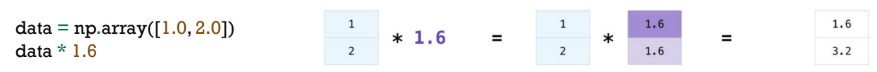

## Numpy Functions

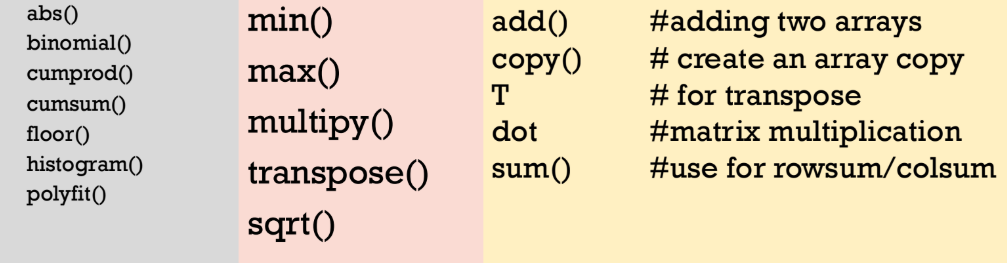